In [1]:
import os 
import numpy as np
import healpy as hp
import mtneedlet as nl
import broom
#import pymaster as nmt
import matplotlib.pyplot as plt
from types import SimpleNamespace
from scipy.stats import kurtosis, skew
%matplotlib inline

from broom import (
    Configs,
    get_params,
    component_separation,_get_full_simulations, estimate_residuals, _combine_products, _compute_spectra)
from broom.needlets import _get_needlet_windows_
from broom.clusters import get_and_save_real_tracers_B

root_path = os.path.dirname(os.path.abspath(broom.__file__))

In [2]:
config_path = root_path + "/configs/config_satellite.yaml"

config: Configs = get_params(config_path=config_path)
print("Loaded configuration from\n", config_path)

Loaded configuration from
 /global/homes/s/sijilj/anaconda3/envs/broom/lib/python3.10/site-packages/broom/configs/config_satellite.yaml


In [3]:
# Here you initialize all the main parameters.
config_values_fg = {
    'lmin': 2, 
    'nside': 2048, 
    'lmax': 4096 , 
    'data_type': "alms", 
    'verbose': True,  
    'nsim_start': 300,
    'nsims': 1,
    'npipe': True,
    'data_type': "alms"
}

# Parameters for generation of simulations.
config_sims_values = {
    'foreground_models': ["d1","s1"], 
    'experiments_file': root_path + "/utils/experiments.yaml",
    'experiment': "Planck_pol",
    'units': "uK_CMB",
    'coordinates': "G"
}


config_values_fg.update(config_sims_values)

config_fg = Configs(config=config_values_fg)

In [4]:
config_inputs_values_fg = {
    'generate_input_foregrounds': False, 
    'return_fgd_components': False,
    'bandpass_integrate': False,
    'generate_input_noise': False, #
    'generate_input_cmb': False,#
    'cls_cmb_path': root_path + "/utils/Cls_Planck2018_lensed_r0.fits",
    'cls_cmb_new_ordered': True,
    'generate_input_data': False, 
    'save_inputs': False,
    'pixel_window_in': False,
    'data_path': "/global/cfs/cdirs/cmb/data/planck2020/npipe/npipe6v20_sim",
    'fgds_path': "/pscratch/sd/s/sijilj/NPIPE_costi/fgds_alms_npipe_nside_2048_TEB.npy",
    'cmb_path': "/global/cfs/cdirs/cmb/data/planck2020/npipe/npipe6v20_sim",
    'noise_path': "/global/cfs/cdirs/cmb/data/planck2020/npipe/npipe6v20_sim",
}

config_values_fg.update(config_inputs_values_fg)

config_fg = Configs(config=config_values_fg)

In [5]:
data = _get_full_simulations(config_fg, nsim = 300)

input lmax : 4096
Loading NPIPE CMB 00300
residue lmax : 4096
Loading NPIPE Noise residual 00300
npipe_alm lmax : 4096


In [6]:
pix_win = hp.pixwin(nside = 1024, pol=True)
pix_win[1][0:2] = np.ones(pix_win[1][0:2].shape)

In [7]:
np.any(pix_win[1] == 0)

False

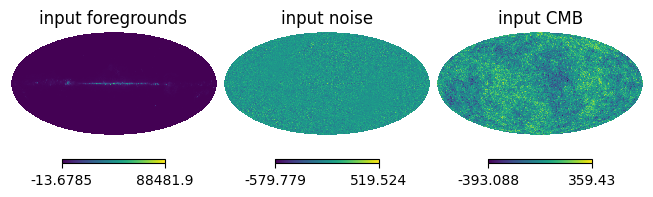

In [35]:


# Let's inspect e.g. B-mode input at a frequency channel

freq_idx = 0
field = 0

# data_type is "alms" in this case..B-mode maps are generated from them
fgds = hp.alm2map(data.fgds[freq_idx,field],config_fg.nside,lmax=config_fg.lmax)*1e6
noise = hp.alm2map(data.noise[freq_idx,field],config_fg.nside,lmax=config_fg.lmax)*1e6
cmb = hp.alm2map(data.cmb[freq_idx,field],config_fg.nside,lmax=config_fg.lmax)*1e6
total = hp.alm2map(data.total[freq_idx,field],config_fg.nside,lmax=config_fg.lmax)*1e6

plt.figure()
hp.mollview(fgds, title="input foregrounds", sub=(1,3,1))
hp.mollview(noise, title="input noise", sub=(1,3,2))
hp.mollview(cmb, title="input CMB", sub=(1,3,3))

# 


In [9]:
hp.Alm.getlmax(12582912, mmax=None)

-1

In [10]:
data.fgds.shape

(7, 3, 8394753)

In [11]:
config_common_cs = {
    'fwhm_out': 5.0, 
    'bring_to_common_resolution': True, 
    'pixel_window_out': False,
    'mask_observations': None,
    'mask_covariance': None,
    'leakage_correction': None,
    'save_compsep_products': True, 
    'return_compsep_products': True, #
    'path_outputs': "outputs/npipe_pol/",
    'field_in': "TEB", 
    'field_out': "TEB",
}

config_values_fg.update(config_common_cs)
config_fg = Configs(config=config_values_fg)

In [12]:
# ILC in needlet domain (NILC)

config_run = {
    'compsep': [{
    'method': "ilc",
    'domain': "needlet", # needlet domain
    'ilc_bias': 0.001,
    # Needlet configuration
    'needlet_config':
      [{'needlet_windows': "cosine"},
       
       {'ell_peaks': [0,100,200,300,400,600,800,1000,1400,1800, 2200, 2600, 3000, 3400, 3800]}],
    # If True, implement a ILC bias correction. 
    'reduce_ilc_bias': False,
    # If True, needlet bands are squared. Therefore needlet transformation is performed just once before component separation. 
    'b_squared': False,
    # If True, the HEALPix resolution of needlet maps is adapted to the sampled range of multipoles.    
    'adapt_nside': True,
    # If True, needlet bands are saved in the specific method path.  
    'save_needlets': True,
    # If True, the weights used to reconstruct the maps are saved in the path specified in path_outputs.
    'save_weights': True,
    # If different from 0. it will debias the covariance matrix by a factor cov_noise_debias * noise_covariance.
    # If float, it will be applied to all needlet bands.
    # If a list each element will be applied to corresponding needlet band.
    # Default = 0.
    'cov_noise_debias': [0.,0.,0.,0.]
}]}

config_values_fg.update(config_run)
config_fg = Configs(config=config_values_fg)
outputs_nilc = component_separation(config_fg, data, nsim = 300)


Pre-processing input alms for component separation for simulation 00300.
Bringing inputs to common resolution
Running component separation for simulation 00300.
Running ilc in needlet domain for simulation 00300.


setting the output map dtype to [dtype('float64'), dtype('float64'), dtype('float64')]
setting the output map dtype to [dtype('float64'), dtype('float64'), dtype('float64')]
setting the output map dtype to [dtype('float64'), dtype('float64'), dtype('float64')]
setting the output map dtype to [dtype('float64'), dtype('float64'), dtype('float64')]


In [13]:
outputs_nilc.cmb[0].shape

(3, 50331648)

In [14]:
outputs_nilc.total[0].shape

(3, 50331648)

## Analysing the results

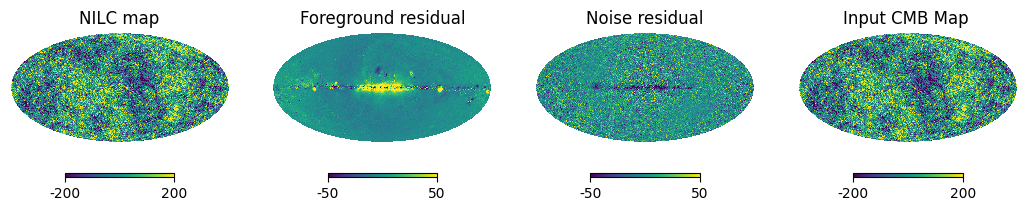

In [37]:
# plotting the maps 
fig, (ax1, ax2, ax3, ax4) = plt.subplots(ncols=4,figsize=(13,8))
plt.axes(ax1)
hp.mollview((outputs_nilc.total[0][0])*1e6,max=200,min=-200,title='NILC map', hold=True)
plt.axes(ax2)
hp.mollview((outputs_nilc.fgds[0][0])*1e6,max=50,min=-50,title='Foreground residual', hold=True)
plt.axes(ax3)
hp.mollview((outputs_nilc.noise[0][0])*1e6,max=50,min=-50,title='Noise residual', hold=True)
plt.axes(ax4)
hp.mollview((outputs_nilc.cmb[0][0])*1e6,max=200,min=-200,title='Input CMB Map ', hold=True)

In [17]:
noise_res_estimate = outputs_nilc.total[0] - outputs_nilc.fgds[0] - outputs_nilc.cmb[0]
cmb_res_estimate = outputs_nilc.total[0] - outputs_nilc.fgds[0] - outputs_nilc.noise[0]

In [18]:
lmax = config_fg.lmax

cl_fg_res = hp.anafast((outputs_nilc.fgds[0])*1e6,lmax =lmax, pol = False)
cl_noise_res_estimate = hp.anafast(noise_res_estimate*1e6,lmax =lmax, pol = False )
cl_cmb_estimate = hp.anafast(cmb_res_estimate*1e6,lmax =lmax, pol = False )
cl_noise_res = hp.anafast(outputs_nilc.noise[0]*1e6,lmax =lmax, pol = False )
cl_nilc = hp.anafast((outputs_nilc.total[0])*1e6,lmax =lmax, pol = False)
cl_cmb = hp.anafast((outputs_nilc.cmb[0])*1e6,lmax =lmax, pol = False)
cl_bias_1 = cl_nilc - cl_cmb - cl_noise_res - cl_fg_res
cl_bias_2 = cl_nilc - cl_cmb - cl_noise_res_estimate - cl_fg_res
cl_bias_3 = cl_nilc - cl_cmb_estimate - cl_noise_res - cl_fg_res
ell = np.arange(lmax+1)



In [19]:
bl_npipe = hp.gauss_beam(np.radians(config_fg.fwhm_out/60),lmax=config_fg.lmax)

Text(0.5, 1.0, 'Angular power spectra of the residue TT')

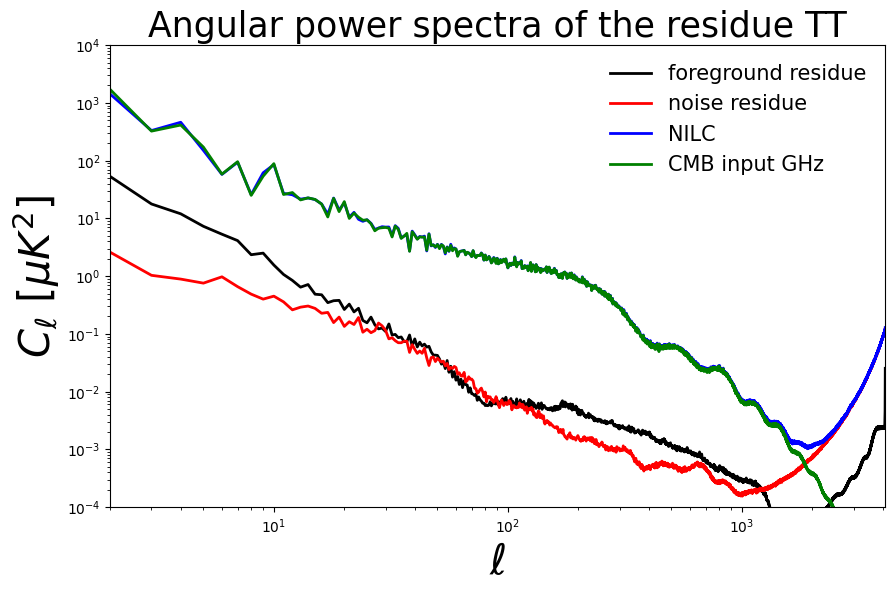

In [20]:
## plotting the power spectra:
plt.figure(figsize=(10,6))
plt.plot(ell,cl_fg_res[0]/(bl_npipe**2),color='k',label='foreground residue',linewidth=2.)
plt.plot(ell,cl_noise_res[0]/(bl_npipe**2),color='r',label='noise residue',linewidth=2.)
plt.plot(ell,cl_nilc[0]/(bl_npipe**2),color='b',label='NILC',linewidth=2.)
plt.plot(ell,cl_cmb[0]/(bl_npipe**2),color='g',label='CMB input GHz',linewidth=2.)
#plt.plot(ell, hp.alm2cl(alm_CMB[0,:,5])*1e12, color= 'y', label = 'CMB Input',linewidth =2. )
#plt.plot(ell,-(cl_cmb -cl_nilc) ,color='orange',label='diff',linewidth=2.)
plt.legend(frameon=False,fontsize=15)
plt.loglog()
plt.xlim(2,lmax)
plt.ylim(1e-4,1e+4)
plt.xlabel("$\ell$", fontsize=30)
plt.ylabel("$C_{\ell}\ [\mu K^{2}]$", fontsize=30)
plt.title("Angular power spectra of the residue TT",fontsize=25.)

Text(0.5, 1.0, 'Angular power spectra of the residue EE')

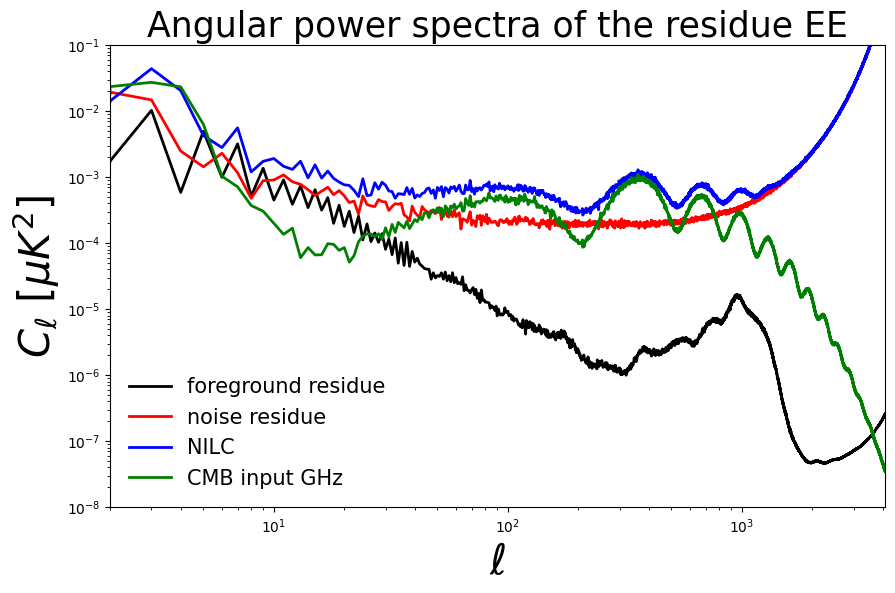

In [21]:
## plotting the power spectra:
plt.figure(figsize=(10,6))
plt.plot(ell,cl_fg_res[1]/(bl_npipe**2),color='k',label='foreground residue',linewidth=2.)
plt.plot(ell,cl_noise_res[1]/(bl_npipe**2),color='r',label='noise residue',linewidth=2.)
plt.plot(ell,cl_nilc[1]/(bl_npipe**2),color='b',label='NILC',linewidth=2.)
plt.plot(ell,cl_cmb[1]/(bl_npipe**2),color='g',label='CMB input GHz',linewidth=2.)
#plt.plot(ell, hp.alm2cl(alm_CMB[0,:,5])*1e12, color= 'y', label = 'CMB Input',linewidth =2. )
#plt.plot(ell,-(cl_cmb -cl_nilc) ,color='orange',label='diff',linewidth=2.)
plt.legend(frameon=False,fontsize=15)
plt.loglog()
plt.xlim(2,lmax)
plt.ylim(1e-8,1e-1)
plt.xlabel("$\ell$", fontsize=30)
plt.ylabel("$C_{\ell}\ [\mu K^{2}]$", fontsize=30)
plt.title("Angular power spectra of the residue EE",fontsize=25.)

Text(0.5, 1.0, 'Angular power spectra of the residue BB')

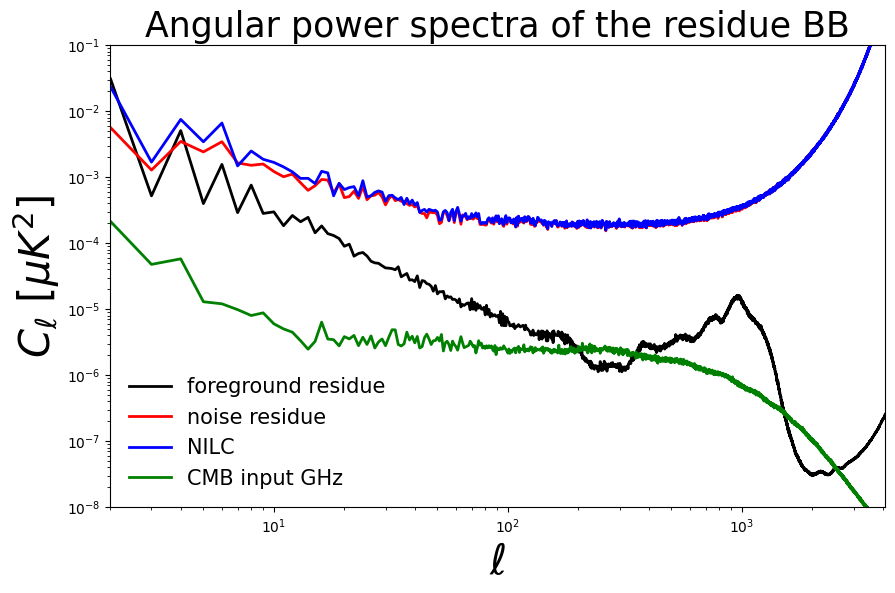

In [22]:
## plotting the power spectra:
plt.figure(figsize=(10,6))
plt.plot(ell,cl_fg_res[2]/(bl_npipe**2),color='k',label='foreground residue',linewidth=2.)
plt.plot(ell,cl_noise_res[2]/(bl_npipe**2),color='r',label='noise residue',linewidth=2.)
plt.plot(ell,cl_nilc[2]/(bl_npipe**2),color='b',label='NILC',linewidth=2.)
plt.plot(ell,cl_cmb[2]/(bl_npipe**2),color='g',label='CMB input GHz',linewidth=2.)
#plt.plot(ell, hp.alm2cl(alm_CMB[0,:,5])*1e12, color= 'y', label = 'CMB Input',linewidth =2. )
#plt.plot(ell,-(cl_cmb -cl_nilc) ,color='orange',label='diff',linewidth=2.)
plt.legend(frameon=False,fontsize=15)
plt.loglog()
plt.xlim(2,lmax)
plt.ylim(1e-8,1e-1)
plt.xlabel("$\ell$", fontsize=30)
plt.ylabel("$C_{\ell}\ [\mu K^{2}]$", fontsize=30)
plt.title("Angular power spectra of the residue BB",fontsize=25.)

## Bias when noise residue from npipe simulations is considered

Text(0.5, 1.0, 'Angular power spectra of the bias BB ')

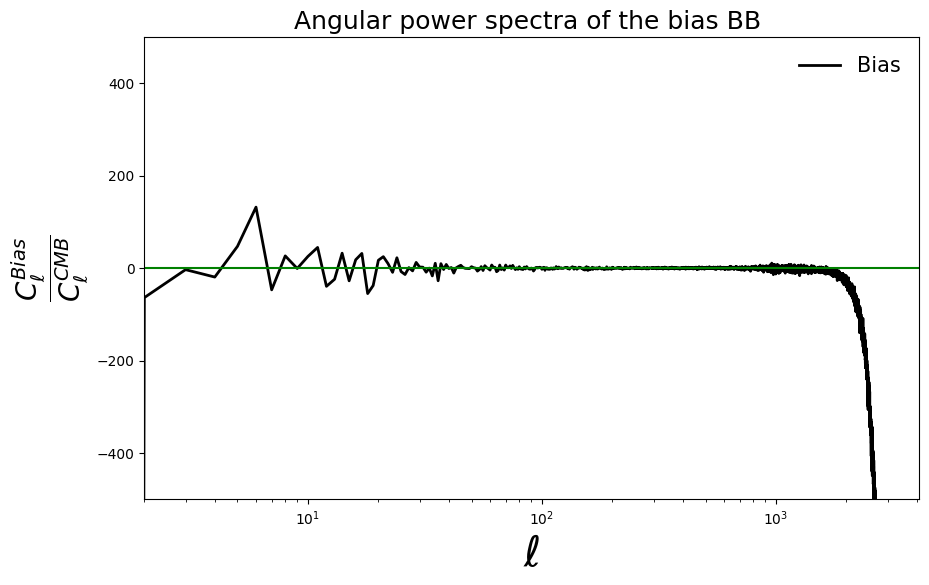

In [69]:
plt.figure(figsize=(10,6))
plt.plot(ell,cl_bias_1[2]/cl_cmb[2],color='k',label='Bias',linewidth=2.)
plt.hlines(0,2,lmax, color = "green")
plt.legend(frameon=False,fontsize=15)
#plt.loglog()
plt.xlim(2,lmax)
plt.ylim(-500,500)
plt.xscale('log')
plt.xlabel("$\ell$", fontsize=30)
plt.ylabel("$\dfrac{C_{\ell}^{Bias}}{C_{\ell}^{CMB}}$", fontsize=20)
plt.title("Angular power spectra of the bias BB ",fontsize=18.)


Text(0.5, 1.0, 'Angular power spectra of the bias TT')

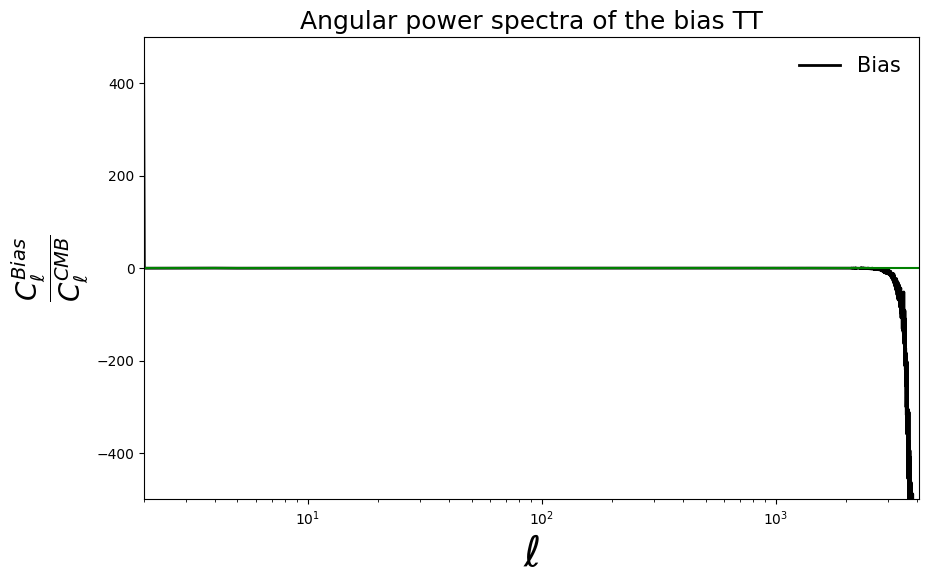

In [68]:
plt.figure(figsize=(10,6))
plt.plot(ell,cl_bias_1[0]/cl_cmb[0],color='k',label='Bias',linewidth=2.)
plt.hlines(0,2,lmax, color = "green")
plt.legend(frameon=False,fontsize=15)
#plt.loglog()
plt.xlim(2,lmax)
plt.ylim(-500,500)
plt.xscale('log')
plt.xlabel("$\ell$", fontsize=30)
plt.ylabel("$\dfrac{C_{\ell}^{Bias}}{C_{\ell}^{CMB}}$", fontsize=20)
plt.title("Angular power spectra of the bias TT",fontsize=18.)

Text(0.5, 1.0, 'Angular power spectra of the bias EE')

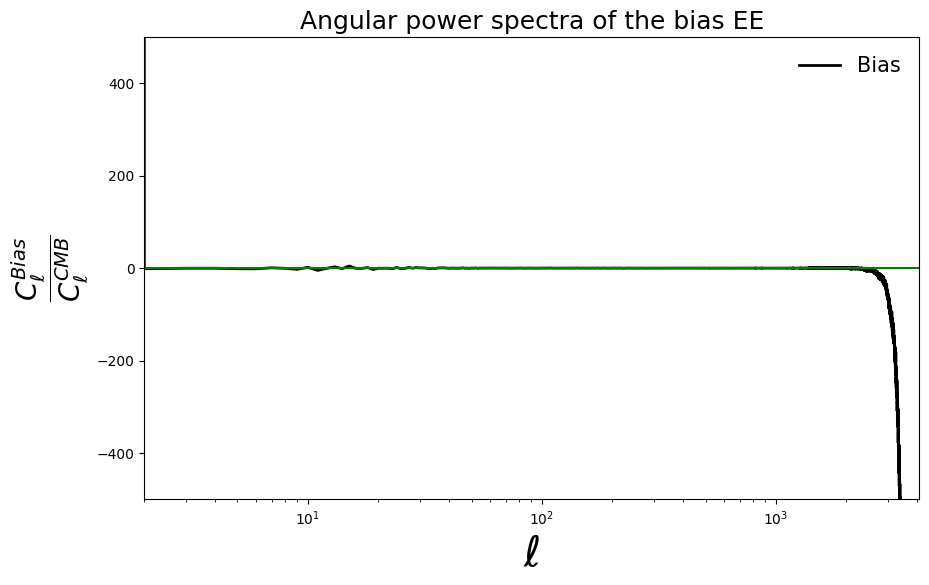

In [67]:
plt.figure(figsize=(10,6))
plt.plot(ell,cl_bias_1[1]/cl_cmb[1],color='k',label='Bias',linewidth=2.)
plt.hlines(0,2,lmax, color = "green")
plt.legend(frameon=False,fontsize=15)
#plt.loglog()
plt.xlim(2,lmax)
plt.ylim(-500,500)
plt.xscale('log')
plt.xlabel("$\ell$", fontsize=30)
plt.ylabel("$\dfrac{C_{\ell}^{Bias}}{C_{\ell}^{CMB}}$", fontsize=20)
plt.title("Angular power spectra of the bias EE",fontsize=18.)

## Bias when noise residue is defined as nilc_out - cmb_res - fg_res

Text(0.5, 1.0, 'Angular power spectra of the bias BB ')

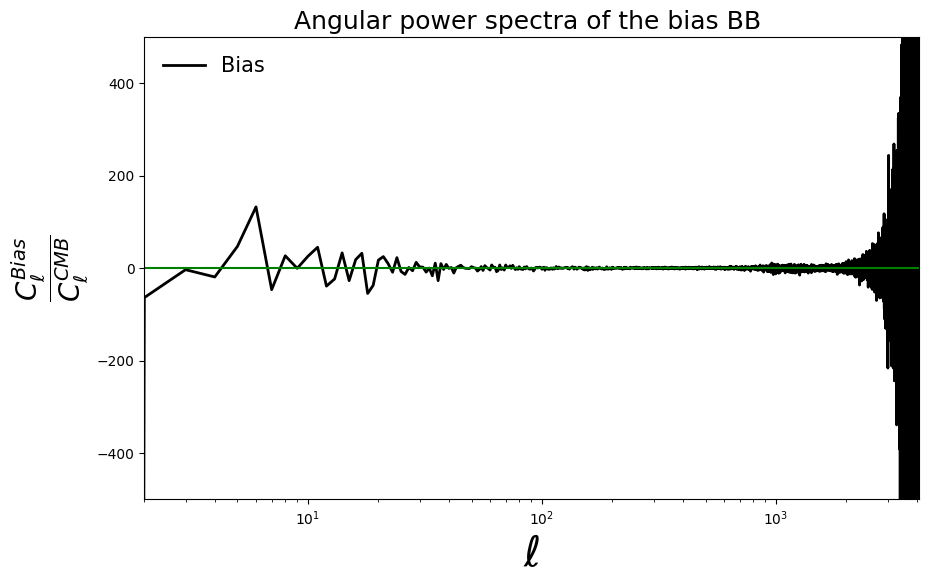

In [66]:
plt.figure(figsize=(10,6))
plt.plot(ell,cl_bias_2[2]/cl_cmb[2],color='k',label='Bias',linewidth=2.)
plt.hlines(0,2,lmax, color = "green")
plt.legend(frameon=False,fontsize=15)
#plt.loglog()
plt.xlim(2,lmax)
plt.ylim(-500,500)
plt.xscale('log')
plt.xlabel("$\ell$", fontsize=30)
plt.ylabel("$\dfrac{C_{\ell}^{Bias}}{C_{\ell}^{CMB}}$", fontsize=20)
plt.title("Angular power spectra of the bias BB ",fontsize=18.)


Text(0.5, 1.0, 'Angular power spectra of the bias TT')

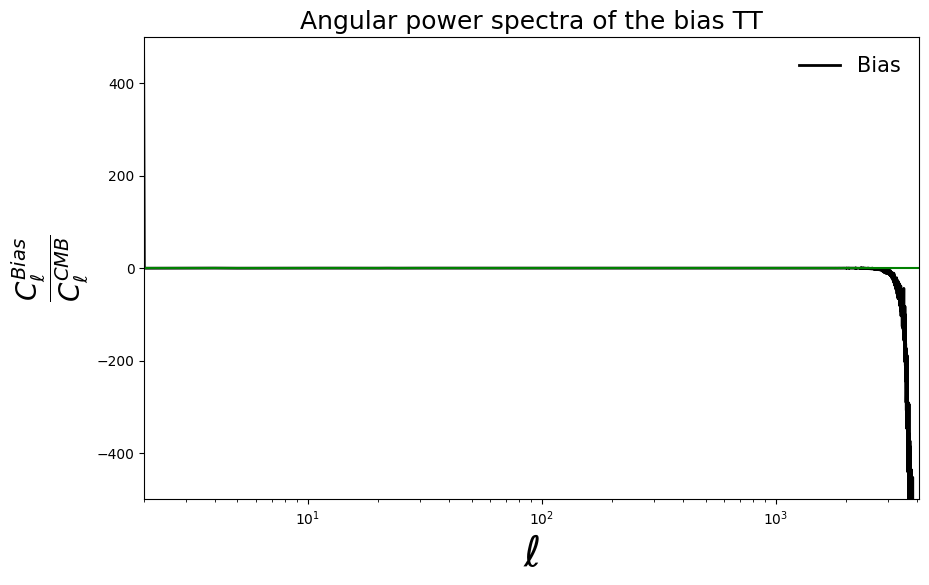

In [65]:
plt.figure(figsize=(10,6))
plt.plot(ell,cl_bias_2[0]/cl_cmb[0],color='k',label='Bias',linewidth=2.)
plt.hlines(0,2,lmax, color = "green")
plt.legend(frameon=False,fontsize=15)
#plt.loglog()
plt.xlim(2,lmax)
plt.ylim(-500,500)
plt.xscale('log')
plt.xlabel("$\ell$", fontsize=30)
plt.ylabel("$\dfrac{C_{\ell}^{Bias}}{C_{\ell}^{CMB}}$", fontsize=20)
plt.title("Angular power spectra of the bias TT",fontsize=18.)

Text(0.5, 1.0, 'Angular power spectra of the bias EE')

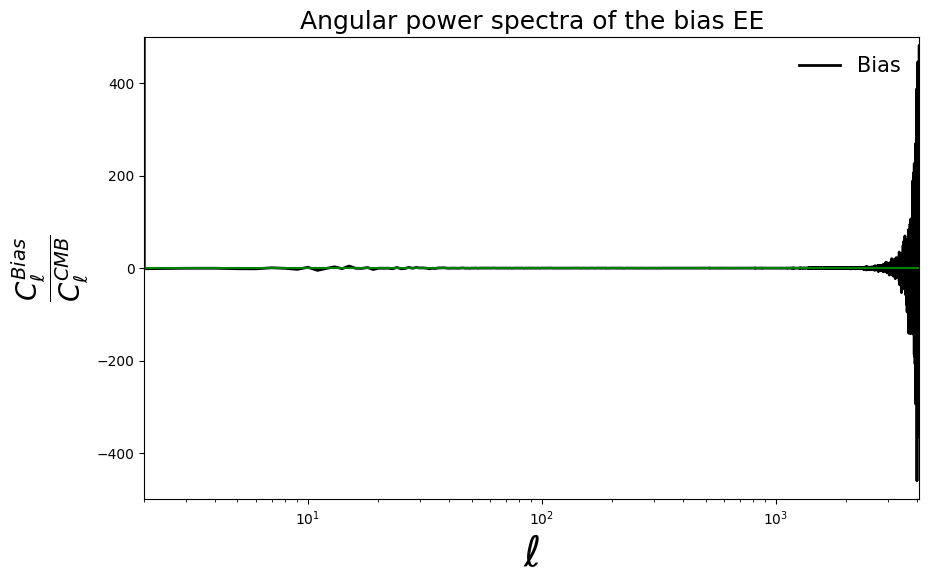

In [63]:
plt.figure(figsize=(10,6))
plt.plot(ell,cl_bias_2[1]/cl_cmb[1],color='k',label='Bias',linewidth=2.)
plt.hlines(0,2,lmax, color = "green")
plt.legend(frameon=False,fontsize=15)
#plt.loglog()
plt.xlim(2,lmax)
plt.ylim(-500,500)
plt.xscale('log')
plt.xlabel("$\ell$", fontsize=30)
plt.ylabel("$\dfrac{C_{\ell}^{Bias}}{C_{\ell}^{CMB}}$", fontsize=20)
plt.title("Angular power spectra of the bias EE",fontsize=18.)

In [30]:
### Comparing noise residue estimate and noise residue

Text(0.5, 1.0, 'Angular power spectra of the residue EE')

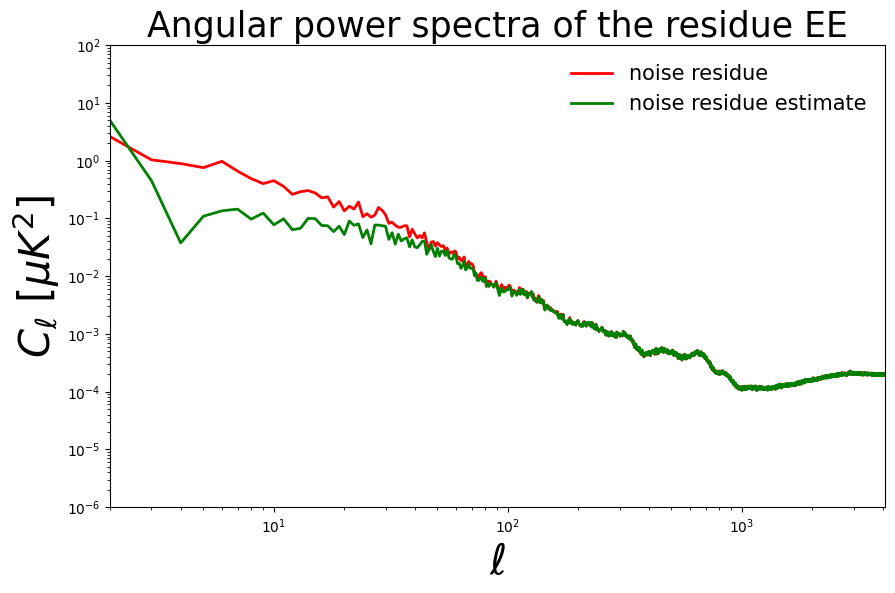

In [31]:
## plotting the power spectra:
plt.figure(figsize=(10,6))
plt.plot(ell,cl_noise_res[0],color='r',label='noise residue',linewidth=2.)
plt.plot(ell,cl_noise_res_estimate[0],color='g',label='noise residue estimate',linewidth=2.)
#plt.plot(ell, hp.alm2cl(alm_CMB[0,:,5])*1e12, color= 'y', label = 'CMB Input',linewidth =2. )
#plt.plot(ell,-(cl_cmb -cl_nilc) ,color='orange',label='diff',linewidth=2.)
plt.legend(frameon=False,fontsize=15)
plt.loglog()
plt.xlim(2,lmax)
plt.ylim(1e-6,1e2)
plt.xlabel("$\ell$", fontsize=30)
plt.ylabel("$C_{\ell}\ [\mu K^{2}]$", fontsize=30)
plt.title("Angular power spectra of the residue EE",fontsize=25.)

/tmp/ipykernel_1654557/4227719720.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False,fontsize=15)


Text(0.5, 1.0, 'Ratio of noise and noise estimate')

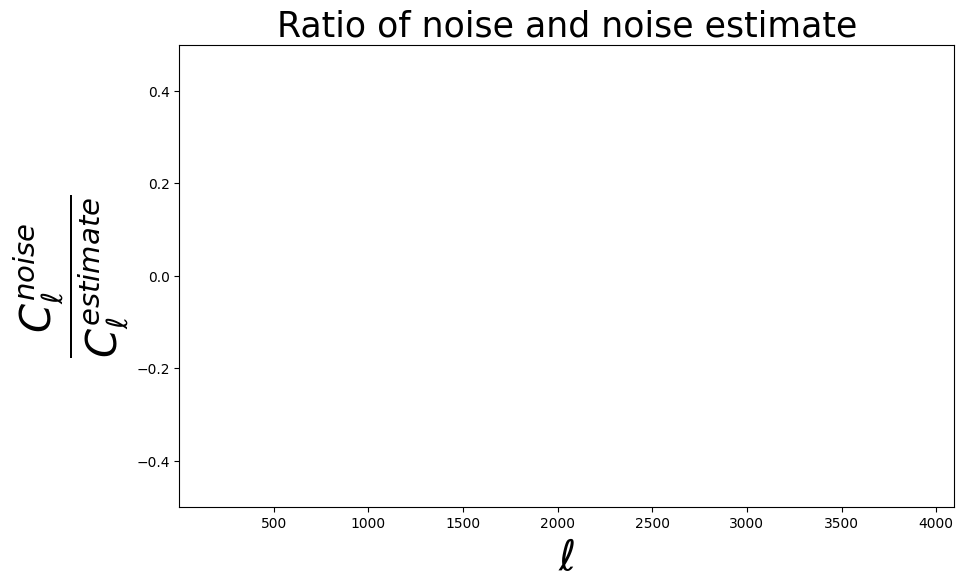

In [70]:
plt.figure(figsize=(10,6))
plt.plot(ell,cl_noise_res[0]/cl_noise_res_estimate[0],color='k',linewidth=2.)
#plt.plot(ell, hp.alm2cl(alm_CMB[0,:,5])*1e12, color= 'y', label = 'CMB Input',linewidth =2. )
#plt.plot(ell,-(cl_cmb -cl_nilc) ,color='orange',label='diff',linewidth=2.)
plt.hlines(1,2,lmax, color = "green")
plt.legend(frameon=False,fontsize=15)
plt.xlim(2,lmax)
plt.ylim(-0.5,0.5)
plt.xlabel("$\ell$", fontsize=30)
plt.ylabel("$\dfrac{C_{\ell}^{noise}}{C_{\ell}^{estimate}}$", fontsize=30)
plt.title("Ratio of noise and noise estimate",fontsize=25.)

/tmp/ipykernel_1654557/3733613421.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False,fontsize=15)


Text(0.5, 1.0, 'Ratio of CMB and CMB estimate')

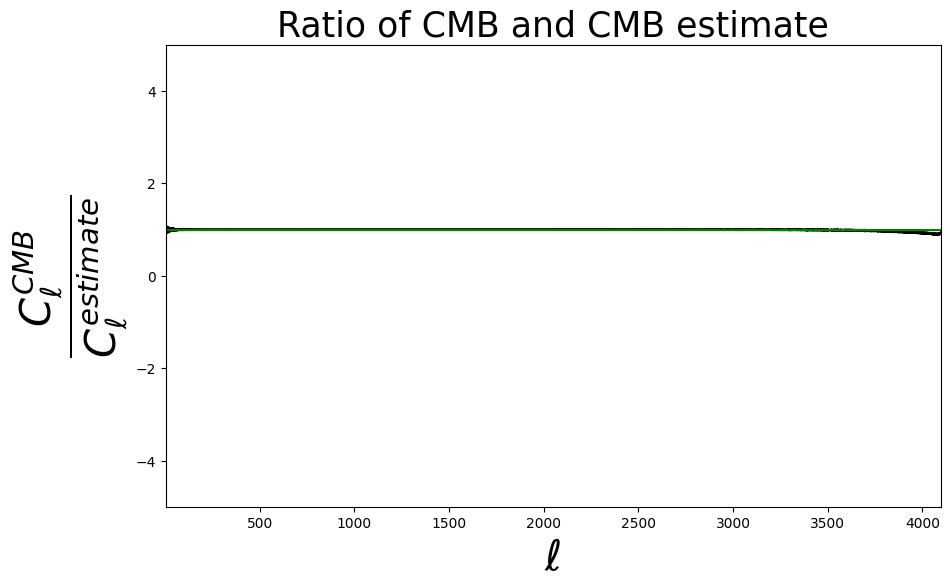

In [53]:
plt.figure(figsize=(10,6))
plt.plot(ell,cl_cmb[0]/cl_cmb_estimate[0],color='k',linewidth=2.)
#plt.plot(ell, hp.alm2cl(alm_CMB[0,:,5])*1e12, color= 'y', label = 'CMB Input',linewidth =2. )
#plt.plot(ell,-(cl_cmb -cl_nilc) ,color='orange',label='diff',linewidth=2.)
plt.hlines(1,2,lmax, color = "green")
plt.legend(frameon=False,fontsize=15)
plt.xlim(2,lmax)
plt.ylim(-5,5)
plt.xlabel("$\ell$", fontsize=30)
plt.ylabel("$\dfrac{C_{\ell}^{CMB}}{C_{\ell}^{estimate}}$", fontsize=30)
plt.title("Ratio of CMB and CMB estimate",fontsize=25.)

## Bias when CMB estimate is used for bias calculation


Text(0.5, 1.0, 'Angular power spectra of the bias BB ')

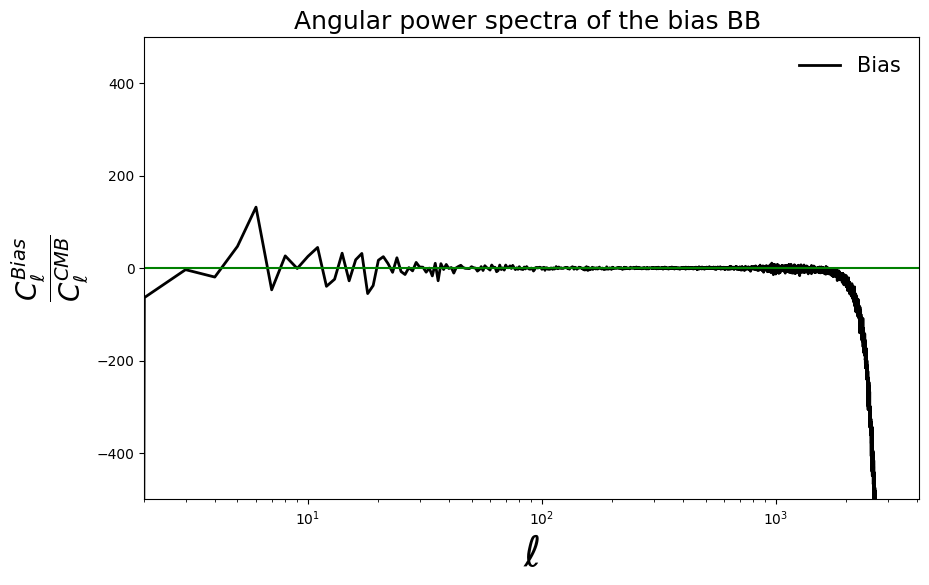

In [60]:
plt.figure(figsize=(10,6))
plt.plot(ell,cl_bias_3[2]/cl_cmb[2],color='k',label='Bias',linewidth=2.)
plt.hlines(0,2,lmax, color = "green")
plt.legend(frameon=False,fontsize=15)
#plt.loglog()
plt.xlim(2,lmax)
plt.ylim(-500,500)
plt.xscale('log')
plt.xlabel("$\ell$", fontsize=30)
plt.ylabel("$\dfrac{C_{\ell}^{Bias}}{C_{\ell}^{CMB}}$", fontsize=20)
plt.title("Angular power spectra of the bias BB ",fontsize=18.)

Text(0.5, 1.0, 'Angular power spectra of the bias EE ')

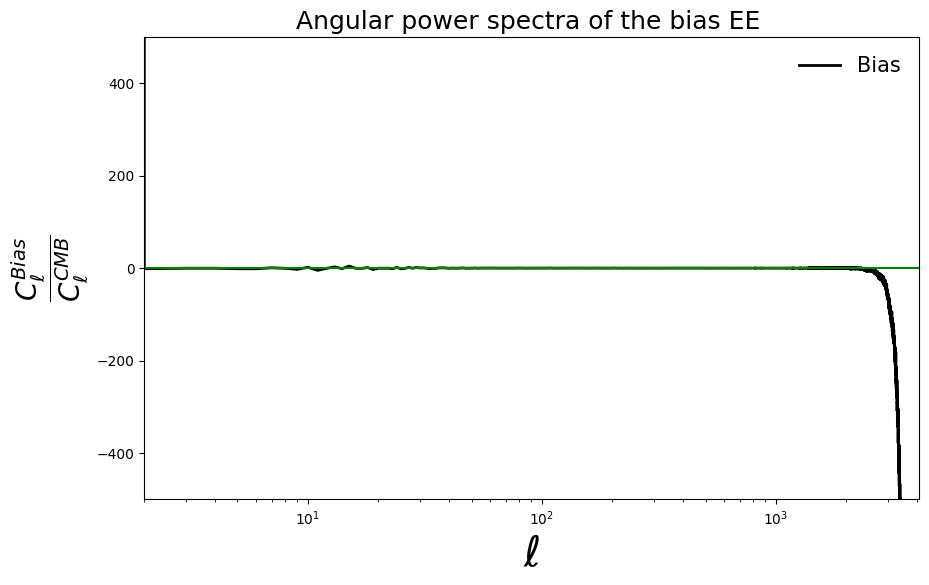

In [61]:
plt.figure(figsize=(10,6))
plt.plot(ell,cl_bias_3[1]/cl_cmb[1],color='k',label='Bias',linewidth=2.)
plt.hlines(0,2,lmax, color = "green")
plt.legend(frameon=False,fontsize=15)
#plt.loglog()
plt.xlim(2,lmax)
plt.ylim(-500,500)
plt.xscale('log')
plt.xlabel("$\ell$", fontsize=30)
plt.ylabel("$\dfrac{C_{\ell}^{Bias}}{C_{\ell}^{CMB}}$", fontsize=20)
plt.title("Angular power spectra of the bias EE ",fontsize=18.)

Text(0.5, 1.0, 'Angular power spectra of the bias TT ')

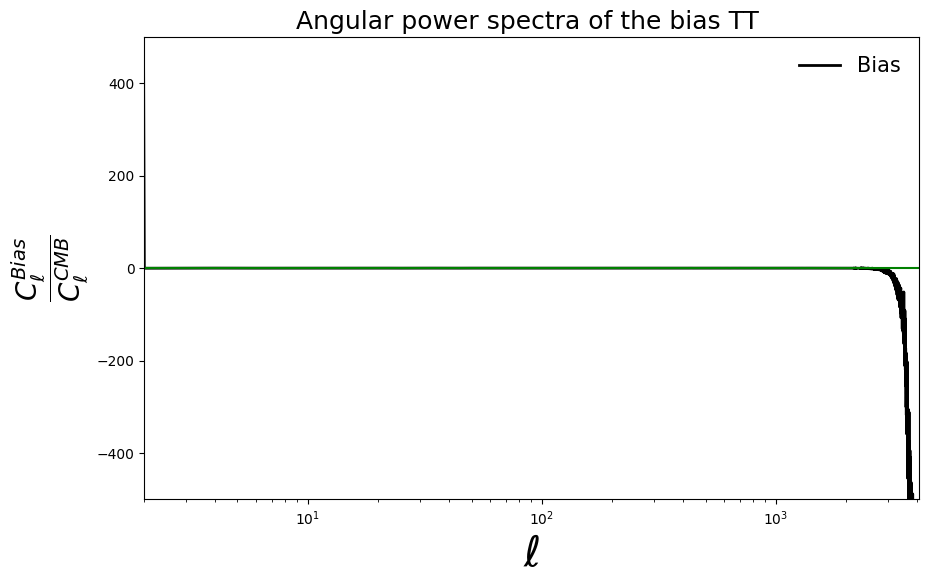

In [62]:
plt.figure(figsize=(10,6))
plt.plot(ell,cl_bias_3[0]/cl_cmb[0],color='k',label='Bias',linewidth=2.)
plt.hlines(0,2,lmax, color = "green")
plt.legend(frameon=False,fontsize=15)
#plt.loglog()
plt.xlim(2,lmax)
plt.ylim(-500,500)
plt.xscale('log')
plt.xlabel("$\ell$", fontsize=30)
plt.ylabel("$\dfrac{C_{\ell}^{Bias}}{C_{\ell}^{CMB}}$", fontsize=20)
plt.title("Angular power spectra of the bias TT ",fontsize=18.)